<a href="https://colab.research.google.com/github/jesusthayna60-gif/custos_de_producao/blob/main/Projeto_Final_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Custos de Produção - Análise de dados

In [28]:
#Importação de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv('y1AQEIpMTR2j7xgr9MH0_Manufacturing Dataset.csv')

In [30]:
df

,Production ID,Date,Product Type,Machine ID,Shift,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent
0,1899-12-31,2020-01-01,Automotive,3,Swing,142,3.0,23.42,38.68,15.38,413.97,1,4.86,1.57,2.34,0.048,1.65,1,22.8,47.2
1,1900-01-01,2020-01-02,Textiles,8,Night,170,4.0,7.51,21.35,25.36,181.16,2,2.51,0.18,1.52,0.030,NaN,1,23.8,37.9
2,1900-01-02,2020-01-03,Appliances,11,Swing,182,4.0,20.58,47.54,16.46,452.15,2,0.34,2.88,0.57,0.026,0.26,0,24.5,56.1
3,1900-01-03,2020-01-04,Appliances,11,Day,133,NaN,21.68,40.21,28.70,485.78,3,4.64,2.23,1.90,0.036,NaN,2,22.3,50.8
4,1900-01-04,2020-01-05,Electronics,14,Night,82,NaN,16.68,38.02,17.20,315.58,1,2.29,0.02,2.25,0.020,0.67,0,23.4,53.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1908-03-14,2028-03-14,Automotive,3,Swing,194,7.0,20.74,16.91,15.94,215.04,4,3.06,2.28,1.03,0.021,0.51,1,21.6,53.6
2996,1908-03-15,2028-03-15,Electronics,13,Swing,119,4.0,14.77,34.50,25.95,291.65,2,2.27,0.80,2.09,0.016,1.22,2,24.2,50.9
2997,2998,2028-03-16,Appliances,9,Day,170,2.0,20.38,33.02,18.61,313.24,1,4.66,1.86,1.41,0.047,0.19,0,24.2,51.4
2998,2999,2028-03-17,Furniture,20,Swing,199,3.0,1.01,24.35,29.73,245.47,3,2.73,0.26,0.93,0.029,1.26,1,24.9,56.3


In [31]:
df.head()

,Production ID,Date,Product Type,Machine ID,Shift,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent
0,1899-12-31,2020-01-01,Automotive,3,Swing,142,3.0,23.42,38.68,15.38,413.97,1,4.86,1.57,2.34,0.048,1.65,1,22.8,47.2
1,1900-01-01,2020-01-02,Textiles,8,Night,170,4.0,7.51,21.35,25.36,181.16,2,2.51,0.18,1.52,0.030,NaN,1,23.8,37.9
2,1900-01-02,2020-01-03,Appliances,11,Swing,182,4.0,20.58,47.54,16.46,452.15,2,0.34,2.88,0.57,0.026,0.26,0,24.5,56.1
3,1900-01-03,2020-01-04,Appliances,11,Day,133,NaN,21.68,40.21,28.70,485.78,3,4.64,2.23,1.90,0.036,NaN,2,22.3,50.8
4,1900-01-04,2020-01-05,Electronics,14,Night,82,NaN,16.68,38.02,17.20,315.58,1,2.29,0.02,2.25,0.020,0.67,0,23.4,53.9


In [32]:
#Cada linha do arquivo CSV representa um único registro de produção, um ciclo de produção descrito pelos dados: ID da Produção, Data, Tipo do Produto, ID da Máquina, Turno

In [33]:
df.columns

Index(['Production ID', 'Date', 'Product Type', 'Machine ID', 'Shift',
       'Units Produced', 'Defects', 'Production Time Hours',
       'Material Cost Per Unit', 'Labour Cost Per Hour',
       'Energy Consumption kWh', 'Operator Count', 'Maintenance Hours',
       'Down time Hours', 'Production Volume Cubic Meters', 'Scrap Rate',
       'Rework Hours', 'Quality Checks Failed', 'Average Temperature C',
       'Average Humidity Percent'],
      dtype='object')

In [34]:
#Calculo de Custos totais de acordo com os dados de produção.
df['Custo Material'] = df['Material Cost Per Unit'] * df['Units Produced']
df['Custo de Mão de Obra'] = df['Labour Cost Per Hour'] * df['Production Time Hours']

#Para calcular o valor da Energia tivemos que adotar um valor para o kWh. Disponível no site: https://clarke.com.br/mapa-de-tarifas-de-energia-no-brasil/#principal
valor_por_kWh = 0.82
df['Custo de Energia'] = df['Energy Consumption kWh'] * valor_por_kWh

df['Custo Total'] = df['Custo Material'] + df['Custo de Mão de Obra'] + df['Custo de Energia']
df['Custo Total']

# O próximo passo é calcular o preço/unidade, para termos um parâmetro padronizado para compações e posteriormente relacionar com outros dados.

df['Custo por Unidade'] = df['Custo Total'] / df['Units Produced']

colunas_custo = ['Date','Product Type','Custo Material',
                 'Custo de Mão de Obra',
                 'Custo de Energia',
                 'Custo Total',
                 'Custo por Unidade']
df[colunas_custo]

,Date,Product Type,Custo Material,Custo de Mão de Obra,Custo de Energia,Custo Total,Custo por Unidade
0,2020-01-01,Automotive,5492.56,360.1996,339.4554,6192.2150,43.607148
1,2020-01-02,Textiles,3629.50,190.4536,148.5512,3968.5048,23.344146
2,2020-01-03,Appliances,8652.28,338.7468,370.7630,9361.7898,51.438405
3,2020-01-04,Appliances,5347.93,622.2160,398.3396,6368.4856,47.883350
4,2020-01-05,Electronics,3117.64,286.8960,258.7756,3663.3116,44.674532
...,...,...,...,...,...,...,...
2995,2028-03-14,Automotive,3280.54,330.5956,176.3328,3787.4684,19.523033
2996,2028-03-15,Electronics,4105.50,383.2815,239.1530,4727.9345,39.730542
2997,2028-03-16,Appliances,5613.40,379.2718,256.8568,6249.5286,36.761933
2998,2028-03-17,Furniture,4845.65,30.0273,201.2854,5076.9627,25.512375


    Ano   Custo Total
0  2020  1.615149e+06
1  2021  1.589898e+06
2  2022  1.535248e+06
3  2023  1.589909e+06
4  2024  1.617597e+06
5  2025  1.537199e+06
6  2026  1.520586e+06
7  2027  1.582097e+06
8  2028  3.373045e+05


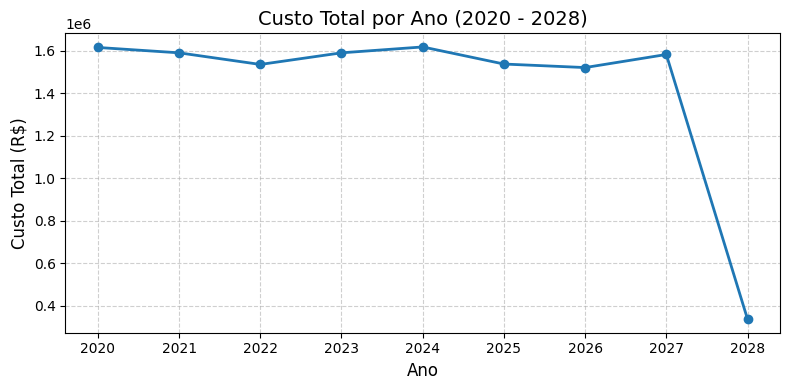

In [35]:
# Criar uma coluna com o ano
df['Date'] = pd.to_datetime(df['Date']) # Convert the 'Date' column to datetime objects
df['Ano'] = df['Date'].dt.year      #É feita uma nova coluna com os dados por ano e não diários

# Agrupar por ano e somar o custo total
custo_anual = df.groupby('Ano')['Custo Total'].sum().reset_index()    #Agrupa os dados por ano e forma um novo DataFrame com colunas "Ano" e "Custo Total"
print(custo_anual)

# Plotar o gráfico dos custos anuais
plt.figure(figsize=(8, 4))
plt.plot(custo_anual['Ano'], custo_anual['Custo Total'], marker='o', linestyle='-', linewidth=2)
plt.title('Custo Total por Ano (2020 - 2028)', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Custo Total (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [36]:
# Cálculo do custo médio por unidade de cada tipo de produto
custo_medio_por_unidade_produto = df.groupby('Product Type')['Custo por Unidade'].mean()
print("Custo Médio por Unidade (R$/Unidade) por Tipo de Produto")
print(round(custo_medio_por_unidade_produto,3))

Custo Médio por Unidade (R$/Unidade) por Tipo de Produto
Product Type
Appliances     34.597
Automotive     34.839
Electronics    35.982
Furniture      36.275
Textiles       34.020
Name: Custo por Unidade, dtype: float64


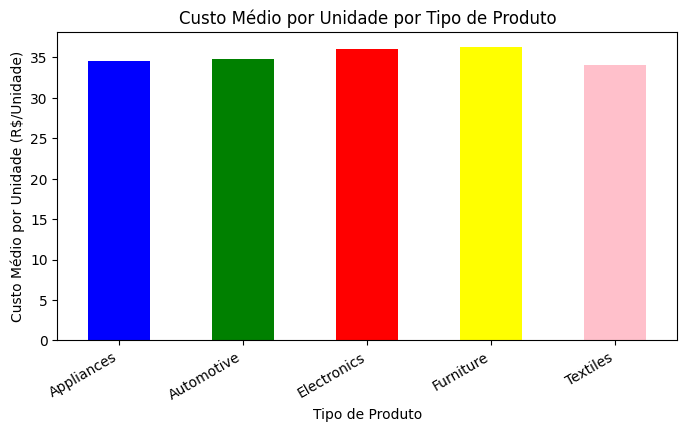

In [37]:
# Gráfico do Custo médio por unidade versus o tipo de produto
plt.figure(figsize=(8, 4))
colors = ['blue', 'green', 'red', 'yellow', 'pink']
custo_medio_por_unidade_produto.plot(kind='bar', color=colors)
plt.title('Custo Médio por Unidade por Tipo de Produto')
plt.xlabel('Tipo de Produto')
plt.ylabel('Custo Médio por Unidade (R$/Unidade)')
plt.xticks(rotation=30, ha='right')
plt.show()

In [38]:
# Calculo do custo médio por tipo de produto para cada custo
custo_medio_por_produto_fragmentado = df.groupby('Product Type')[['Custo Material', 'Custo de Mão de Obra', 'Custo de Energia']].mean()

print("Custo Médio por Tipo de Produto para cada custo (R$)")
print(round(custo_medio_por_produto_fragmentado, 2))

Custo Médio por Tipo de Produto para cada custo (R$)
              Custo Material  Custo de Mão de Obra  Custo de Energia
Product Type                                                        
Appliances           3703.02                269.12            248.00
Automotive           3906.45                287.96            244.44
Electronics          3741.49                288.76            247.39
Furniture            3871.90                296.66            247.74
Textiles             3661.75                283.39            242.25


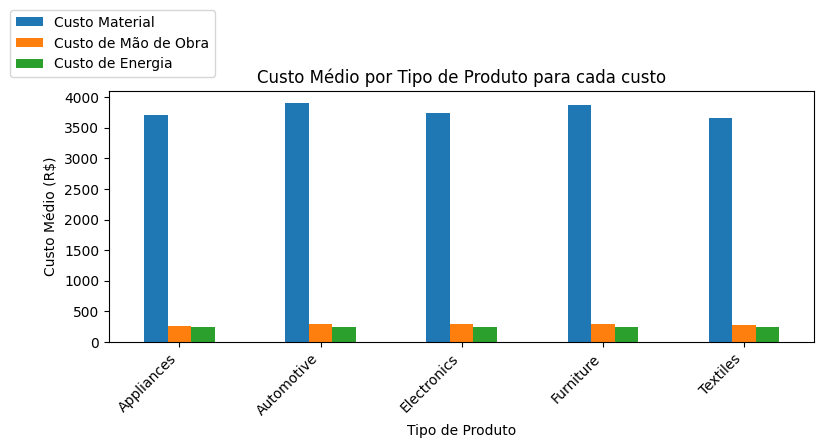

In [39]:
# Gráfico do Custo médio por tipo de produto para cada custo
custo_medio_por_produto_fragmentado.plot(kind='bar', figsize=(8, 4))
plt.title('Custo Médio por Tipo de Produto para cada custo')
plt.xlabel('Tipo de Produto')
plt.ylabel('Custo Médio (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(-0.15, 1.35))
plt.show()

In [40]:
# Observamos que os valores médios de produção de cada tipo de produto são proximos.
# Não parece tão relevante uma comparação entre eles.
# Vamos analizar a influência de cada custo.

custo_total_material = df['Custo Material'].sum()
custo_total_labour = df['Custo de Mão de Obra'].sum()
custo_total_energy = df['Custo de Energia'].sum()

custo_total_absoluto = df['Custo Total'].sum()
print('O custo total da indústria é R$', round(custo_total_absoluto,2))

# Calculo de porcentagens:
custo_total_material_percent = (custo_total_material / custo_total_absoluto) * 100
custo_total_labour_percent = (custo_total_labour / custo_total_absoluto) * 100
custo_total_energy_percent = (custo_total_energy / custo_total_absoluto) * 100

#Exibição dos resultados
print('A porcentagem do custo de material é de: ', round(custo_total_material_percent, 2), '%')
print('A porcentagem do custo de mão de obra é de: ', round(custo_total_labour_percent,2), '%')
print('A porcentagem do custo de energia é de: ', round(custo_total_energy_percent,2), '%')

O custo total da indústria é R$ 12924988.11
A porcentagem do custo de material é de:  87.68 %
A porcentagem do custo de mão de obra é de:  6.61 %
A porcentagem do custo de energia é de:  5.71 %


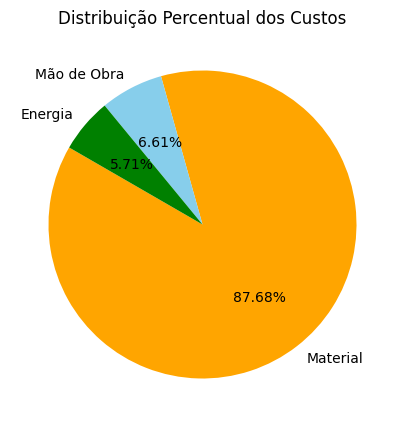

In [41]:
# Dados para o gráfico de pizza relacionando os tipos de custos da indústria
labels = ['Material', 'Mão de Obra', 'Energia']
custos_porcentagens = [custo_total_material_percent,
         custo_total_labour_percent,
         custo_total_energy_percent]
colors = ['orange', 'skyblue', 'green']

plt.figure(figsize=(10, 5))
plt.pie(custos_porcentagens, labels=labels, colors=colors, autopct='%1.2f%%', startangle=150)
plt.title('Distribuição Percentual dos Custos')
plt.show()

In [42]:
# Para saber quais colunas se relacionam melhor com o Custo do Material, fizemos o Coeficiente de Pearson:

# Excluir colunas não numéricas antes de calcular a correlação
numeric_df = df.drop(columns=['Production ID', 'Date', 'Product Type', 'Shift'])

correlation_results = numeric_df.corr()['Custo Material'].sort_values(ascending=False)
correlation_results = correlation_results.drop('Custo Material')

print("\n--- Coeficiente de Correlação de Pearson (Todas as Colunas vs. Custo Material) ---")
print(correlation_results)

# Valores Próximos de +1 (Correlação Positiva Forte)
# Valores Próximos de -1 (Correlação Negativa Forte)
# Valores Próximos de 0 (Correlação Fraca/Nula)



--- Coeficiente de Correlação de Pearson (Todas as Colunas vs. Custo Material) ---
Custo Total                       0.995568
Material Cost Per Unit            0.721697
Units Produced                    0.644677
Custo por Unidade                 0.601523
Defects                           0.029717
Scrap Rate                        0.020840
Down time Hours                   0.017355
Energy Consumption kWh            0.013541
Custo de Energia                  0.013541
Custo de Mão de Obra              0.005232
Production Time Hours             0.005136
Operator Count                    0.004576
Labour Cost Per Hour              0.002619
Machine ID                       -0.001648
Quality Checks Failed            -0.002912
Production Volume Cubic Meters   -0.010635
Average Humidity Percent         -0.013155
Ano                              -0.017653
Average Temperature C            -0.018421
Maintenance Hours                -0.026957
Rework Hours                     -0.034298
Name: Custo M

In [43]:
#Conclui-se que o custo do mateial não é algo que tem interfencia das outras variaveis.

#logo cabe fazer um programa para fazer com que a industria compre o material mais barato.
#Pois existe muitas discrepâncias entre os valores, veja:

df[['Custo Total', 'Custo Material', 'Material Cost Per Unit', 'Units Produced']]

,Custo Total,Custo Material,Material Cost Per Unit,Units Produced
0,6192.2150,5492.56,38.68,142
1,3968.5048,3629.50,21.35,170
2,9361.7898,8652.28,47.54,182
3,6368.4856,5347.93,40.21,133
4,3663.3116,3117.64,38.02,82
...,...,...,...,...
2995,3787.4684,3280.54,16.91,194
2996,4727.9345,4105.50,34.50,119
2997,6249.5286,5613.40,33.02,170
2998,5076.9627,4845.65,24.35,199


In [44]:
# Vamos padronizar as entradas dos materiais de acordo um valor estabelecido:
custo__media_unidade_appliances = 29.79
custo__media_unidade_automotive = 30.11
custo__media_unidade_electronics = 30.85
custo__media_unidade_furniture = 31.20
custo__media_unidade_textiles = 29.19

whife = True
tipos_produto_unicos = df['Product Type'].unique()
print("Tipos de peças produzidas:")
for i, tipo in enumerate(tipos_produto_unicos):
    print(f"{i+1}: {tipo}",)

print("")
tipo_escolhido = int(input("Escolha o número do tipo de produto deseja comprar? "))
quantidade_pecas = int(input("Qual a quantidade de peças que deseja comprar? "))

if tipo_escolhido == 1:
    custo_atual_automotive = custo__media_unidade_automotive * quantidade_pecas
    print(f"O valor dessa compra atualmente na industria é de R$ {custo_atual_automotive:.2f}")
elif tipo_escolhido == 2:
    custo_atual_appliances = custo__media_unidade_appliances * quantidade_pecas
    print(f"O valor dessa compra atualmente na industria é de R$ {custo_atual_appliances:.2f}")
elif tipo_escolhido == 3:
    custo_atual_electronics = custo__media_unidade_electronics * quantidade_pecas
    print(f"O valor dessa compra atualmente na industria é de R$ {custo_atual_electronics:.2f}")
elif tipo_escolhido == 4:
    custo_atual_furniture = custo__media_unidade_furniture * quantidade_pecas
    print(f"O valor dessa compra atualmente na industria é de R$ {custo_atual_furniture:.2f}")
elif tipo_escolhido == 5:
    custo_atual_textiles = custo__media_unidade_textiles * quantidade_pecas
    print(f"O valor dessa compra atualmente na industria é de R$ {custo_atual_textiles:.2f}")
else:
    print("Opção inválida. Por favor, escolha um número válido.")


Tipos de peças produzidas:
1: Automotive
2: Textiles
3: Appliances
4: Electronics
5: Furniture

Escolha o número do tipo de produto deseja comprar? 5
Qual a quantidade de peças que deseja comprar? 45
O valor dessa compra atualmente na industria é de R$ 1313.55


In [45]:
#Com esse dado se pode ter um parâmetro para saber se o materia está caro ou barato
#Caso a fábrica deseje reduzir o custo, pode-se optar por comprar o material <= o valor atual.